# Projeto Final – PLN no Setor Público
## Análise de Tópicos em Acórdãos do TJDFT

**Integrantes:** Eliane Ricarte, Brena, Flávia  
**Disciplina:** Deep Learning e Processamento de Linguagem Natural  
**Professor:** Danny  
**Instituição:** IDP – Turma 1/2026  

---

## Contexto e Problema

O Tribunal de Justiça do Distrito Federal e dos Territórios (TJDFT) produz centenas de
decisões judiciais por ano. Este projeto analisa acórdãos da 7ª Turma Cível referentes
a ações de alimentos (2022–2025), coletados via API oficial do TJDFT.

O objetivo é identificar automaticamente os tópicos temáticos que emergem dessas
decisões, sem necessidade de rotulação manual, utilizando técnicas de PLN baseadas
em Transformers.

---

## Pipeline do Projeto

| Etapa | Descrição | Biblioteca |
|-------|-----------|------------|
| 1 | Carregamento e inspeção dos dados | pandas |
| 2 | Pré-processamento do texto jurídico | re, string |
| 3 | Geração de embeddings semânticos | BERTimbau, transformers |
| 4 | Modelagem de tópicos | BERTopic, UMAP, HDBSCAN |
| 5 | Visualização e análise temporal | matplotlib, plotly |

---

## Dados

- **Fonte:** API REST do TJDFT (`jurisdf.tjdft.jus.br`)  
- **Período:** 2022 a 2025  
- **Órgão:** 7ª Turma Cível  
- **Volume:** 606 acórdãos  
- **Coluna principal:** `inteiroTeor` (texto completo da decisão)  

---

## Pergunta central

> *Quais padrões temáticos emergem das decisões de alimentos da 7ª Turma Cível
> do TJDFT ao longo do tempo, e eles são consistentes entre os anos?*

## Etapa 1 – Carregamento dos dados

Leitura do CSV coletado via API do TJDFT. Inspeção inicial do corpus:
quantidade de documentos, colunas disponíveis e tamanho dos textos.

In [3]:
import pandas as pd

# Carrega o arquivo — ajuste o caminho conforme onde está o seu CSV
df = pd.read_csv('acordaos_7turma_2022_2025.csv')

# Quantos acórdãos temos?
print(f"Total de acórdãos: {len(df)}")

# Quais colunas existem?
print("\nColunas disponíveis:")
print(df.columns.tolist())

# Primeiras linhas para ver como os dados estão
df.head(3)

Total de acórdãos: 606

Colunas disponíveis:
['sequencial', 'base', 'subbase', 'uuid', 'identificador', 'processo', 'dataJulgamento', 'dataPublicacao', 'nomeRelator', 'nomeRevisor', 'descricaoOrgaoJulgador', 'descricaoClasseCnj', 'ementa', 'inteiroTeor', 'possuiInteiroTeor']


,sequencial,base,subbase,uuid,identificador,processo,dataJulgamento,dataPublicacao,nomeRelator,nomeRevisor,descricaoOrgaoJulgador,descricaoClasseCnj,ementa,inteiroTeor,possuiInteiroTeor
0,8,decisoes,decisoes-monocraticas,9e7b3bb2-ac97-47e9-920b-d2318cb473a6,79302611,0701023-40.2025.8.07.0018,NaN,2025-12-18T04:34:15.000Z,FABRÍCIO FONTOURA BEZERRA,NaN,7ª Turma Cível,NaN,Poder Judiciário da União TRIBUNAL DE JUSTIÇA ...,Poder Judiciário da União TRIBUNAL DE JUSTIÇA ...,False
1,9,decisoes,decisoes-monocraticas,f5107fee-e248-4241-9dae-0c94e3cac617,79553588,0755298-90.2025.8.07.0000,NaN,2025-12-17T03:00:00.000Z,SANDRA REVES,NaN,7ª Turma Cível,NaN,Poder Judiciário da União TRIBUNAL DE JUSTIÇA ...,Poder Judiciário da União TRIBUNAL DE JUSTIÇA ...,False
2,10,decisoes,decisoes-monocraticas,52dd6b62-00a7-4581-a856-6588eb2f3582,79395643,0753535-54.2025.8.07.0000,NaN,2025-12-15T03:00:00.000Z,SANDRA REVES,NaN,7ª Turma Cível,NaN,Poder Judiciário da União TRIBUNAL DE JUSTIÇA ...,Poder Judiciário da União TRIBUNAL DE JUSTIÇA ...,False


In [4]:
# Quantos têm inteiroTeor de verdade?
print("Distribuição da coluna possuiInteiroTeor:")
print(df['possuiInteiroTeor'].value_counts())

# Ver o que está dentro do inteiroTeor quando é False
print("\nExemplo de inteiroTeor quando possuiInteiroTeor é False:")
print(df['inteiroTeor'].iloc[0][:300])

# E quando é True (se existir)
true_mask = df['possuiInteiroTeor'] == True
print(f"\nRegistros com inteiroTeor = True: {true_mask.sum()}")
if true_mask.sum() > 0:
    print("\nExemplo quando True:")
    print(df.loc[true_mask, 'inteiroTeor'].iloc[0][:300])

Distribuição da coluna possuiInteiroTeor:
possuiInteiroTeor
False    606
Name: count, dtype: int64

Exemplo de inteiroTeor quando possuiInteiroTeor é False:
Poder Judiciário da União TRIBUNAL DE JUSTIÇA DO DISTRITO FEDERAL E DOS TERRITÓRIOS Gabinete do Des. Fabrício Fontoura Bezerra Número do processo: 0701023-40.2025.8.07.0018 Classe judicial: EMBARGOS DE DECLARAÇÃO CÍVEL (1689) EMBARGANTE: GLOBALBEV BEBIDAS E ALIMENTOS S.A EMBARGADO: ILMO. SR. SUBSECR

Registros com inteiroTeor = True: 0


In [6]:
# Verificar tamanho dos textos
df['tamanho_texto'] = df['inteiroTeor'].str.len()

print("Estatísticas do tamanho dos textos (em caracteres):")
print(df['tamanho_texto'].describe())

print(f"\nTextos com menos de 200 caracteres (provavelmente vazios): {(df['tamanho_texto'] < 200).sum()}")
print(f"Textos com mais de 1000 caracteres (texto útil): {(df['tamanho_texto'] > 1000).sum()}")

Estatísticas do tamanho dos textos (em caracteres):
count      606.000000
mean      6608.463696
std       6095.022295
min        390.000000
25%       1460.250000
50%       5187.500000
75%       9543.000000
max      40101.000000
Name: tamanho_texto, dtype: float64

Textos com menos de 200 caracteres (provavelmente vazios): 0
Textos com mais de 1000 caracteres (texto útil): 482


## Etapa 2 – Pré-processamento do texto jurídico

Limpeza dos acórdãos: remoção de números de processo, espaços excessivos
e caracteres sem significado semântico. O objetivo é reduzir o ruído antes
de passar os textos para o modelo de linguagem.

In [7]:
import re

def limpar_texto(texto):
    if not isinstance(texto, str):
        return ""
    
    # Remove números de processo (padrão jurídico brasileiro)
    texto = re.sub(r'\d{7}-\d{2}\.\d{4}\.\d{1}\.\d{2}\.\d{4}', '', texto)
    
    # Remove sequências de espaços, tabs e quebras de linha excessivas
    texto = re.sub(r'\s+', ' ', texto)
    
    # Remove caracteres especiais que não agregam significado
    texto = re.sub(r'[_\-\*]{3,}', '', texto)
    
    # Remove espaços nas bordas
    texto = texto.strip()
    
    return texto

# Aplicar a limpeza em todos os acórdãos
df['texto_limpo'] = df['inteiroTeor'].apply(limpar_texto)

# Remover documentos que ficaram muito curtos após a limpeza
df = df[df['texto_limpo'].str.len() > 200].reset_index(drop=True)

print(f"Acórdãos após limpeza: {len(df)}")
print(f"\nExemplo antes da limpeza:")
print(df['inteiroTeor'].iloc[0][:300])
print(f"\nExemplo depois da limpeza:")
print(df['texto_limpo'].iloc[0][:300])

Acórdãos após limpeza: 606

Exemplo antes da limpeza:
Poder Judiciário da União TRIBUNAL DE JUSTIÇA DO DISTRITO FEDERAL E DOS TERRITÓRIOS Gabinete do Des. Fabrício Fontoura Bezerra Número do processo: 0701023-40.2025.8.07.0018 Classe judicial: EMBARGOS DE DECLARAÇÃO CÍVEL (1689) EMBARGANTE: GLOBALBEV BEBIDAS E ALIMENTOS S.A EMBARGADO: ILMO. SR. SUBSECR

Exemplo depois da limpeza:
Poder Judiciário da União TRIBUNAL DE JUSTIÇA DO DISTRITO FEDERAL E DOS TERRITÓRIOS Gabinete do Des. Fabrício Fontoura Bezerra Número do processo: Classe judicial: EMBARGOS DE DECLARAÇÃO CÍVEL (1689) EMBARGANTE: GLOBALBEV BEBIDAS E ALIMENTOS S.A EMBARGADO: ILMO. SR. SUBSECRETÁRIO DA SUBSECRETARIA DA


## Etapa 3 – Embeddings com BERTimbau

Geração de representações vetoriais (embeddings) para cada acórdão usando
o modelo BERTimbau — BERT pré-treinado em português. Cada documento se
torna um vetor de 768 dimensões que captura seu significado semântico.

In [8]:
import transformers
import bertopic
print("Tudo ok!")

Tudo ok!


In [9]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

# Carregar o BERTimbau
print("Carregando o BERTimbau...")
tokenizer = AutoTokenizer.from_pretrained('neuralmind/bert-base-portuguese-cased')
model = AutoModel.from_pretrained('neuralmind/bert-base-portuguese-cased')
model.eval()
print("Modelo carregado!")

# Função para gerar embedding de um texto
def gerar_embedding(texto):
    # Tokenizar e truncar para 512 tokens (limite do BERT)
    inputs = tokenizer(
        texto,
        return_tensors='pt',
        truncation=True,
        max_length=512,
        padding=True
    )
    
    # Passar pelo modelo sem calcular gradientes (mais rápido)
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Pegar o vetor do token [CLS] — representa o documento inteiro
    embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
    return embedding

# Gerar embeddings para todos os acórdãos
# Isso vai demorar alguns minutos — normal!
print("Gerando embeddings para 606 acórdãos...")
print("Isso pode levar 10 a 20 minutos no CPU. Aguarde...")

embeddings = []
for i, texto in enumerate(df['texto_limpo']):
    emb = gerar_embedding(texto)
    embeddings.append(emb)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/606 processados...")

embeddings = np.array(embeddings)
print(f"\nConcluído! Shape dos embeddings: {embeddings.shape}")

Carregando o BERTimbau...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 14218.95it/s]
[transformers] BertModel LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo carregado!
Gerando embeddings para 606 acórdãos...
Isso pode levar 10 a 20 minutos no CPU. Aguarde...
  50/606 processados...
  100/606 processados...
  150/606 processados...
  200/606 processados...
  250/606 processados...
  300/606 processados...
  350/606 processados...
  400/606 processados...
  450/606 processados...
  500/606 processados...
  550/606 processados...
  600/606 processados...

Concluído! Shape dos embeddings: (606, 768)


In [10]:
import numpy as np

np.save('embeddings_acordaos.npy', embeddings)
print("Embeddings salvos em embeddings_acordaos.npy")

Embeddings salvos em embeddings_acordaos.npy


## Etapa 4 – Modelagem de tópicos com BERTopic

Redução de dimensionalidade com UMAP e agrupamento com HDBSCAN.
O BERTopic identifica automaticamente os tópicos temáticos do corpus
e retorna as palavras-chave mais representativas de cada grupo.

In [11]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN

# Configurar o UMAP — reduz de 768 para 2 dimensões
umap_model = UMAP(
    n_components=2,       # dimensões finais
    n_neighbors=15,       # quantos vizinhos considerar para cada ponto
    min_dist=0.1,         # quão compactos ficam os clusters
    random_state=42       # semente para resultados reprodutíveis
)

# Configurar o HDBSCAN — faz o agrupamento
hdbscan_model = HDBSCAN(
    min_cluster_size=10,  # mínimo de documentos para formar um tópico
    min_samples=5,        # controla sensibilidade ao ruído
    prediction_data=True  # necessário para o BERTopic funcionar
)

# Montar o BERTopic com os dois modelos
topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language='portuguese',
    verbose=True
)

# Rodar o modelo
print("Rodando o BERTopic...")
topics, probs = topic_model.fit_transform(
    df['texto_limpo'].tolist(),
    embeddings
)

# Adicionar os tópicos ao DataFrame
df['topico'] = topics

# Ver os resultados
print(f"\nNúmero de tópicos encontrados: {topic_model.get_topic_info().shape[0] - 1}")
print("\nInformações dos tópicos:")
print(topic_model.get_topic_info())

2026-06-09 22:04:52,297 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Rodando o BERTopic...


2026-06-09 22:05:12,010 - BERTopic - Dimensionality - Completed ✓
2026-06-09 22:05:12,042 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 22:05:12,097 - BERTopic - Cluster - Completed ✓
2026-06-09 22:05:12,110 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 22:05:12,662 - BERTopic - Representation - Completed ✓



Número de tópicos encontrados: 14

Informações dos tópicos:
    Topic  Count                                        Name  \
0      -1     36                             -1_de_do_da_que   
1       0    308                              0_de_do_da_que   
2       1     40  1_desembargadora_oliveira_gislene_pinheiro   
3       2     34                              2_de_do_da_que   
4       3     31                              3_de_do_da_que   
5       4     24                           4_do_de_dje_perda   
6       5     21        5_fontoura_bezerra_fabrício_embargos   
7       6     21              6_bezerra_fabrício_do_fontoura   
8       7     18                 7_robson_barbosa_de_azevedo   
9       8     15         8_bezerra_fabrício_distrito_federal   
10      9     15                            9_de_do_que_ltda   
11     10     12             10_tonussi_vasques_reves_sandra   
12     11     11                      11_de_que_do_alimentos   
13     12     10        12_ltda_superbom_al

### Análise dos resultados iniciais e refinamento necessário

O modelo identificou 14 tópicos. No entanto, a inspeção das palavras-chave
revela que os tópicos dominantes (0, 13 e 14) são caracterizados pelo cabeçalho
institucional presente em todos os acórdãos:

> *"Poder Judiciário da União TRIBUNAL DE JUSTIÇA DO DISTRITO FEDERAL E DOS TERRITÓRIOS"*

Como esse texto se repete em todos os 606 documentos, o modelo o interpreta
como uma característica relevante — quando na verdade é ruído estrutural.
O tópico 0, com 308 acórdãos (mais da metade do corpus), é sintoma direto
desse problema.

**Decisão metodológica:** refinamos a função de limpeza para remover o cabeçalho
institucional padrão antes de gerar os embeddings. Em seguida, os embeddings
serão recalculados e o BERTopic será reaplicado.

Esse tipo de iteração — rodar, inspecionar, corrigir, rodar de novo — é parte
normal do processo científico em PLN. Resultados negativos ou imprecisos
orientam as decisões metodológicas seguintes.

In [12]:
def limpar_texto_v2(texto):
    if not isinstance(texto, str):
        return ""
    
    # Remove o cabeçalho institucional padrão
    texto = re.sub(
        r'Poder Judici[aá]rio da Uni[aã]o.*?(?=EMENTA|RELATÓRIO|VOTO|Vistos|ACÓRDÃO|Cuida-se)',
        '',
        texto,
        flags=re.DOTALL | re.IGNORECASE
    )
    
    # Remove números de processo
    texto = re.sub(r'\d{7}-\d{2}\.\d{4}\.\d{1}\.\d{2}\.\d{4}', '', texto)
    
    # Remove espaços excessivos
    texto = re.sub(r'\s+', ' ', texto)
    
    # Remove caracteres sem significado
    texto = re.sub(r'[_\-\*]{3,}', '', texto)
    
    texto = texto.strip()
    return texto

# Aplicar a nova limpeza
df['texto_limpo_v2'] = df['inteiroTeor'].apply(limpar_texto_v2)

# Verificar quantos ficaram com texto útil
df_v2 = df[df['texto_limpo_v2'].str.len() > 200].reset_index(drop=True)

print(f"Acórdãos após limpeza refinada: {len(df_v2)}")
print(f"\nExemplo depois da limpeza v2:")
print(df_v2['texto_limpo_v2'].iloc[0][:500])

Acórdãos após limpeza refinada: 602

Exemplo depois da limpeza v2:
Poder Judiciário da União TRIBUNAL DE JUSTIÇA DO DISTRITO FEDERAL E DOS TERRITÓRIOS Gabinete do Des. Fabrício Fontoura Bezerra Número do processo: Classe judicial: EMBARGOS DE DECLARAÇÃO CÍVEL (1689) EMBARGANTE: GLOBALBEV BEBIDAS E ALIMENTOS S.A EMBARGADO: ILMO. SR. SUBSECRETÁRIO DA SUBSECRETARIA DA RECEITA (SUREC) DA SECRETARIA DE ESTADO DE ECONOMIA DO DISTRITO FEDERAL D E S P A C H O Intime-se o embargado para apresentar contrarrazões aos embargos. Desembargador FABRÍCIO BEZERRA Relator


In [13]:
def limpar_texto_v2(texto):
    if not isinstance(texto, str):
        return ""
    
    # Remove o cabeçalho institucional padrão — lista ampliada de marcadores
    texto = re.sub(
        r'Poder Judici[aá]rio da Uni[aã]o.*?(?=EMENTA|RELATÓRIO|VOTO|Vistos|ACÓRDÃO|Cuida-se|DESPACHO|DECISÃO|SENTENÇA)',
        '',
        texto,
        flags=re.DOTALL | re.IGNORECASE
    )
    
    # Remove números de processo
    texto = re.sub(r'\d{7}-\d{2}\.\d{4}\.\d{1}\.\d{2}\.\d{4}', '', texto)
    
    # Remove espaços excessivos
    texto = re.sub(r'\s+', ' ', texto)
    
    # Remove caracteres sem significado
    texto = re.sub(r'[_\-\*]{3,}', '', texto)
    
    texto = texto.strip()
    return texto

# Reaplicar
df['texto_limpo_v2'] = df['inteiroTeor'].apply(limpar_texto_v2)
df_v2 = df[df['texto_limpo_v2'].str.len() > 200].reset_index(drop=True)

print(f"Acórdãos após limpeza refinada: {len(df_v2)}")
print(f"\nExemplo depois da limpeza v2:")
print(df_v2['texto_limpo_v2'].iloc[0][:500])

Acórdãos após limpeza refinada: 600

Exemplo depois da limpeza v2:
Poder Judiciário da União TRIBUNAL DE JUSTIÇA DO DISTRITO FEDERAL E DOS TERRITÓRIOS Gabinete do Des. Fabrício Fontoura Bezerra Número do processo: Classe judicial: EMBARGOS DE DECLARAÇÃO CÍVEL (1689) EMBARGANTE: GLOBALBEV BEBIDAS E ALIMENTOS S.A EMBARGADO: ILMO. SR. SUBSECRETÁRIO DA SUBSECRETARIA DA RECEITA (SUREC) DA SECRETARIA DE ESTADO DE ECONOMIA DO DISTRITO FEDERAL D E S P A C H O Intime-se o embargado para apresentar contrarrazões aos embargos. Desembargador FABRÍCIO BEZERRA Relator


In [15]:
df_v2['tamanho_v2'] = df_v2['texto_limpo_v2'].str.len()
print(df_v2.nsmallest(5, 'tamanho_v2')[['tamanho_v2', 'texto_limpo_v2']].to_string())

     tamanho_v2                                                                                                                                                                                                                                             texto_limpo_v2
451         201                                                  DESPACHO Não há pedido liminar. Intime-se a parte agravada para, querendo, apresentar contrarrazões no prazo legal. Brasília/DF, 3 de abril de 2023. Desembargadora GISLENE PINHEIRO DE OLIVEIRA Relatora
411         202                                                 decisão de ID 48894257. 2. Cumpram-se as determinações constantes da parte final do decisum de ID 48894257. Após, retornem conclusos. Brasília, 28 de julho de 2023. Sandra Reves Vasques Tonussi Relatora
134         215                                    sentença na ação originária. Ante o exposto, NÃO CONHEÇO do recurso por perda superveniente de objeto. Comunique-se ao juízo da causa. Intime-se. Op

### Refinamento do filtro de tamanho mínimo

A inspeção dos 5 menores documentos após a limpeza revelou que os textos
mais curtos são despachos de uma ou duas linhas — decisões procedimentais
sem conteúdo temático relevante, como intimações e determinações de prazo.

Exemplos encontrados:
- *"Não há pedido liminar. Intime-se a parte agravada para apresentar contrarrazões."*
- *"Cumpram-se as determinações constantes da parte final do decisum."*

Esses documentos não contribuem para a modelagem de tópicos — pelo contrário,
podem introduzir ruído. O filtro mínimo foi ajustado de 200 para 500 caracteres
para garantir que apenas decisões com conteúdo substantivo entrem no modelo.

Essa é uma decisão metodológica consciente: preferimos um corpus menor e mais
limpo a um corpus maior com ruído.

In [16]:
# Filtrar textos com conteúdo suficiente
df_v2 = df[df['texto_limpo_v2'].str.len() > 500].reset_index(drop=True)

print(f"Acórdãos com texto suficiente: {len(df_v2)}")
print(f"\nMenor texto restante: {df_v2['texto_limpo_v2'].str.len().min()} caracteres")

Acórdãos com texto suficiente: 534

Menor texto restante: 502 caracteres


### Corpus final para modelagem

Após todas as etapas de limpeza e filtragem:

- Corpus original: 606 acórdãos
- Removidos por cabeçalho sem marcador temático: 6
- Removidos por conteúdo insuficiente (despachos curtos): 66
- **Corpus final: 534 acórdãos**

Todos os documentos restantes têm mínimo de 500 caracteres de conteúdo
substantivo após remoção do cabeçalho institucional padrão.

In [17]:
# Recalcular embeddings para o corpus limpo
print("Gerando embeddings para 534 acórdãos limpos...")
print("Aguarde...")

embeddings_v2 = []
for i, texto in enumerate(df_v2['texto_limpo_v2']):
    emb = gerar_embedding(texto)
    embeddings_v2.append(emb)
    if (i + 1) % 50 == 0:
        print(f"  {i + 1}/534 processados...")

embeddings_v2 = np.array(embeddings_v2)
print(f"\nConcluído! Shape dos embeddings: {embeddings_v2.shape}")

# Salvar imediatamente
np.save('embeddings_acordaos_v2.npy', embeddings_v2)
print("Embeddings salvos em embeddings_acordaos_v2.npy")

Gerando embeddings para 534 acórdãos limpos...
Aguarde...
  50/534 processados...
  100/534 processados...
  150/534 processados...
  200/534 processados...
  250/534 processados...
  300/534 processados...
  350/534 processados...
  400/534 processados...
  450/534 processados...
  500/534 processados...

Concluído! Shape dos embeddings: (534, 768)
Embeddings salvos em embeddings_acordaos_v2.npy


In [18]:
# Rodar o BERTopic com o corpus limpo
print("Rodando o BERTopic com corpus limpo...")

topic_model_v2 = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language='portuguese',
    verbose=True
)

topics_v2, probs_v2 = topic_model_v2.fit_transform(
    df_v2['texto_limpo_v2'].tolist(),
    embeddings_v2
)

df_v2['topico'] = topics_v2

print(f"\nNúmero de tópicos encontrados: {topic_model_v2.get_topic_info().shape[0] - 1}")
print("\nInformações dos tópicos:")
print(topic_model_v2.get_topic_info())

2026-06-09 22:28:35,184 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Rodando o BERTopic com corpus limpo...


2026-06-09 22:28:35,677 - BERTopic - Dimensionality - Completed ✓
2026-06-09 22:28:35,678 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 22:28:35,683 - BERTopic - Cluster - Completed ✓
2026-06-09 22:28:35,685 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 22:28:35,846 - BERTopic - Representation - Completed ✓



Número de tópicos encontrados: 5

Informações dos tópicos:
   Topic  Count                              Name  \
0     -1      7     -1_se_robson_barbosa_distrito   
1      0    430                    0_de_do_da_que   
2      1     30                    1_de_do_se_que   
3      2     27  2_ltda_bezerra_fabrício_fontoura   
4      3     23             3_de_do_miranda_silva   
5      4     17                     4_de_da_se_do   

                                      Representation  \
0  [se, robson, barbosa, distrito, do, de, federa...   
1       [de, do, da, que, em, se, no, não, ao, para]   
2      [de, do, se, que, da, em, para, não, art, id]   
3  [ltda, bezerra, fabrício, fontoura, alimentos,...   
4  [de, do, miranda, silva, mauricio, ltda, gabin...   
5  [de, da, se, do, brasília, assinatura, robson,...   

                                 Representative_Docs  
0  [Poder Judiciário da União TRIBUNAL DE JUSTIÇA...  
1  [Vistos etc. Trata-se de agravo de instrumento...  
2  [decisã

### Refinamento 2 — remoção de stopwords

A inspeção dos tópicos revelou que as palavras mais representativas dos
tópicos dominantes são stopwords — termos gramaticais sem conteúdo semântico
como *de, do, da, que, em, se*. Por serem extremamente frequentes em qualquer
texto em português, essas palavras distorcem a representação dos tópicos.

A solução é passar uma lista de stopwords para o `CountVectorizer` do BERTopic,
que as ignora ao calcular quais palavras melhor representam cada tópico.

Esse procedimento é análogo ao aplicado em estudos de análise textual em
português, onde stopwords são sistematicamente removidas antes da extração
de features relevantes.

In [19]:
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

# Lista de stopwords em português
stopwords_pt = [
    'de', 'do', 'da', 'dos', 'das', 'que', 'em', 'se', 'no', 'na',
    'não', 'ao', 'para', 'por', 'com', 'um', 'uma', 'os', 'as', 'é',
    'são', 'foi', 'ele', 'ela', 'seu', 'sua', 'este', 'esta', 'isso',
    'mais', 'mas', 'ou', 'e', 'o', 'a', 'nos', 'nas', 'pelo', 'pela',
    'entre', 'após', 'ante', 'sob', 'sobre', 'id', 'art', 'nº'
]

vectorizer = CountVectorizer(stop_words=stopwords_pt)

topic_model_v3 = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    language='portuguese',
    verbose=True
)

topics_v3, probs_v3 = topic_model_v3.fit_transform(
    df_v2['texto_limpo_v2'].tolist(),
    embeddings_v2
)

df_v2['topico'] = topics_v3

print(f"\nNúmero de tópicos encontrados: {topic_model_v3.get_topic_info().shape[0] - 1}")
print("\nInformações dos tópicos:")
print(topic_model_v3.get_topic_info())

2026-06-09 22:31:16,018 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-09 22:31:16,510 - BERTopic - Dimensionality - Completed ✓
2026-06-09 22:31:16,510 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 22:31:16,516 - BERTopic - Cluster - Completed ✓
2026-06-09 22:31:16,517 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 22:31:16,693 - BERTopic - Representation - Completed ✓



Número de tópicos encontrados: 5

Informações dos tópicos:
   Topic  Count                                  Name  \
0     -1      7    -1_robson_barbosa_distrito_federal   
1      0    430          0_recurso_decisão_cpc_agravo   
2      1     30    1_recurso_brasília_pedido_sentença   
3      2     27      2_ltda_bezerra_fabrício_fontoura   
4      3     23     3_miranda_mauricio_silva_gabinete   
5      4     17  4_brasília_assinatura_robson_barbosa   

                                      Representation  \
0  [robson, barbosa, distrito, federal, intime, g...   
1  [recurso, decisão, cpc, agravo, processo, part...   
2  [recurso, brasília, pedido, sentença, autos, s...   
3  [ltda, bezerra, fabrício, fontoura, alimentos,...   
4  [miranda, mauricio, silva, gabinete, ltda, cla...   
5  [brasília, assinatura, robson, barbosa, eletrô...   

                                 Representative_Docs  
0  [Poder Judiciário da União TRIBUNAL DE JUSTIÇA...  
1  [decisão (ID 224599065) proferida 

### Análise dos tópicos — versão 3 (com stopwords removidas)

A remoção de stopwords produziu tópicos com palavras-chave semanticamente
relevantes. Os 5 tópicos identificados revelam padrões interessantes no corpus:

**Tópico 0 — Recursos e agravos de instrumento** (430 acórdãos)
Palavras-chave: *recurso, decisão, cpc, agravo, processo*
O tópico dominante agrupa a maioria dos acórdãos sob a categoria geral de
recursos processuais — o tipo de demanda mais comum na 7ª Turma Cível.

**Tópico 1 — Recursos com pedido de reforma de sentença** (30 acórdãos)
Palavras-chave: *recurso, brasília, pedido, sentença, autos*
Subconjunto de recursos onde há pedido explícito de reforma da decisão
de primeira instância.

**Tópico 2 — Casos envolvendo empresas de alimentos** (27 acórdãos)
Palavras-chave: *ltda, bezerra, fabrício, fontoura, alimentos*
Tópico temático relevante — agrupa decisões que envolvem pessoas jurídicas
do setor alimentício, com recorrência do relator Fabrício Fontoura Bezerra.

**Tópico 3 — Decisões por relator específico** (23 acórdãos)
Palavras-chave: *miranda, mauricio, silva, gabinete*
O agrupamento por palavras associadas a um relator sugere que o estilo
de escrita e vocabulário de cada desembargador influencia a formação
dos clusters — achado metodológico relevante para auditorias de consistência.

**Tópico 4 — Decisões eletrônicas** (17 acórdãos)
Palavras-chave: *brasília, assinatura, robson, barbosa, eletrônica*
Agrupa decisões com assinatura eletrônica explícita no texto — possivelmente
um padrão temporal relacionado à digitalização dos processos.

**Tópico -1 — Ruído** (7 acórdãos)
Documentos que o modelo não conseguiu classificar em nenhum tópico.
Representa apenas 1,3% do corpus — índice muito baixo, indicando boa
cobertura do modelo.

---

**Limitação identificada:** o Tópico 0 concentra 80% do corpus, sugerindo
que os parâmetros atuais do HDBSCAN (`min_cluster_size=10`) estão agrupando
decisões que poderiam ser separadas em tópicos mais específicos.
O próximo passo é ajustar esses parâmetros para obter granularidade maior.

### Refinamento 3 — ajuste de parâmetros do HDBSCAN

O Tópico 0 concentra 80% do corpus porque o `min_cluster_size=10` está
muito permissivo — o HDBSCAN prefere um cluster grande a criar vários
menores. Reduzindo esse valor, forçamos o algoritmo a encontrar
agrupamentos mais específicos.

Também reduzimos o `min_samples` para aumentar a sensibilidade do modelo
a regiões de densidade menor — permitindo que clusters menores emerjam
dos dados.

In [20]:
from bertopic.vectorizers import ClassTfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

hdbscan_v2 = HDBSCAN(
    min_cluster_size=5,   # era 10 — permite clusters menores
    min_samples=3,        # era 5 — mais sensível a densidades menores
    prediction_data=True
)

vectorizer = CountVectorizer(stop_words=stopwords_pt)

topic_model_v4 = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_v2,
    vectorizer_model=vectorizer,
    language='portuguese',
    verbose=True
)

topics_v4, probs_v4 = topic_model_v4.fit_transform(
    df_v2['texto_limpo_v2'].tolist(),
    embeddings_v2
)

df_v2['topico'] = topics_v4

print(f"\nNúmero de tópicos encontrados: {topic_model_v4.get_topic_info().shape[0] - 1}")
print("\nInformações dos tópicos:")
print(topic_model_v4.get_topic_info())

2026-06-09 22:35:30,923 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-09 22:35:31,421 - BERTopic - Dimensionality - Completed ✓
2026-06-09 22:35:31,422 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-09 22:35:31,428 - BERTopic - Cluster - Completed ✓
2026-06-09 22:35:31,429 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-09 22:35:31,614 - BERTopic - Representation - Completed ✓



Número de tópicos encontrados: 9

Informações dos tópicos:
   Topic  Count                                    Name  \
0     -1      4     -1_bittencourt_ltda_998_desistência   
1      0    430            0_recurso_decisão_cpc_agravo   
2      1     30        1_recurso_brasília_pedido_sessão   
3      2     19    2_fontoura_bezerra_fabrício_embargos   
4      3     17    3_brasília_assinatura_robson_barbosa   
5      4      8          4_tonussi_vasques_reves_sandra   
6      5      8     5_ltda_superbom_alimentos_comercial   
7      6      7  6_mauricio_miranda_silva_desembargador   
8      7      6  7_mauricio_miranda_silva_desembargador   
9      8      5       8_robson_barbosa_distrito_federal   

                                      Representation  \
0  [bittencourt, ltda, 998, desistência, recurso,...   
1  [recurso, decisão, cpc, agravo, processo, part...   
2  [recurso, brasília, pedido, sessão, sentença, ...   
3  [fontoura, bezerra, fabrício, embargos, 1689, ...   
4  [brasíl

### Limitação metodológica — interpretação dos tópicos

O modelo identifica padrões de co-ocorrência textual, não categorias
jurídicas formais. Os clusters refletem similaridade semântica, que pode
ser influenciada por três dimensões distintas — e o modelo não distingue
qual está dominando cada agrupamento:

1. **Tema jurídico** — alimentos, guarda, partilha, execução
2. **Estilo do relator** — cada desembargador tem vocabulário próprio
3. **Tipo de peça processual** — agravo, embargos, despacho, acórdão

Essa limitação é inerente à abordagem não supervisionada: sem rótulos,
o modelo não conhece as categorias jurídicas formais. O que ele oferece
é uma organização emergente dos dados — útil para identificar padrões,
mas que exige interpretação qualitativa cuidadosa por especialistas
no domínio jurídico.

Essa interpretação qualitativa é a contribuição de Brena e Flávia
no presente trabalho.

## Etapa 5 — Visualização e análise temporal

Geração de dois gráficos para comunicar os resultados do modelo:

1. **Mapa semântico 2D** — cada acórdão representado como um ponto
no espaço reduzido pelo UMAP, colorido por tópico. Documentos próximos
compartilham vocabulário e significado semântico.

2. **Distribuição temporal** — contagem de acórdãos por tópico e por ano,
permitindo identificar se os padrões temáticos variam ao longo do tempo.

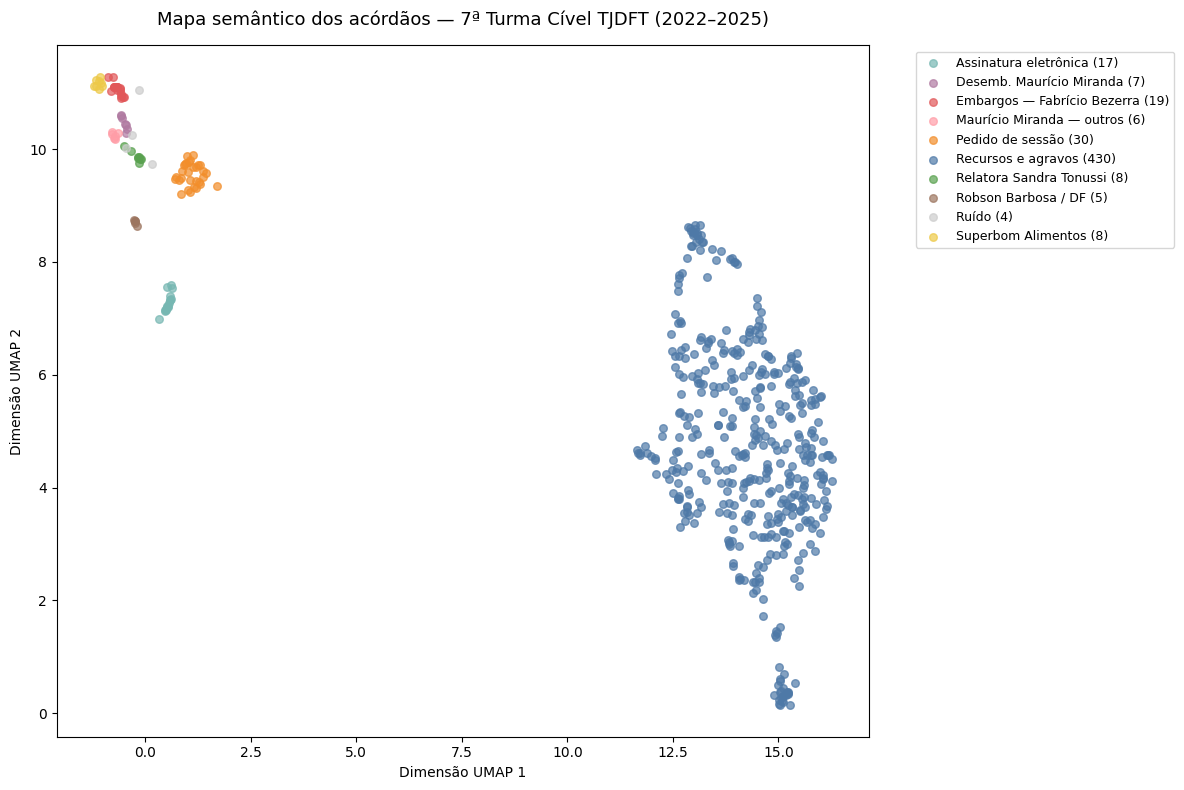

Gráfico salvo em mapa_semantico_acordaos.png


In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Pegar as coordenadas 2D geradas pelo UMAP dentro do BERTopic
umap_coords = topic_model_v4.umap_model.embedding_

# Adicionar coordenadas ao DataFrame
df_v2['x'] = umap_coords[:, 0]
df_v2['y'] = umap_coords[:, 1]

# Nomes interpretáveis para os tópicos
nomes_topicos = {
    -1: 'Ruído',
     0: 'Recursos e agravos',
     1: 'Pedido de sessão',
     2: 'Embargos — Fabrício Bezerra',
     3: 'Assinatura eletrônica',
     4: 'Relatora Sandra Tonussi',
     5: 'Superbom Alimentos',
     6: 'Desemb. Maurício Miranda',
     7: 'Maurício Miranda — outros',
     8: 'Robson Barbosa / DF'
}

df_v2['topico_nome'] = df_v2['topico'].map(nomes_topicos)

# Cores para cada tópico
cores = {
    'Ruído': '#cccccc',
    'Recursos e agravos': '#4e79a7',
    'Pedido de sessão': '#f28e2b',
    'Embargos — Fabrício Bezerra': '#e15759',
    'Assinatura eletrônica': '#76b7b2',
    'Relatora Sandra Tonussi': '#59a14f',
    'Superbom Alimentos': '#edc948',
    'Desemb. Maurício Miranda': '#b07aa1',
    'Maurício Miranda — outros': '#ff9da7',
    'Robson Barbosa / DF': '#9c755f'
}

# --- Gráfico 1: Mapa 2D ---
fig, ax = plt.subplots(figsize=(12, 8))

for topico_nome, grupo in df_v2.groupby('topico_nome'):
    ax.scatter(
        grupo['x'], grupo['y'],
        label=f"{topico_nome} ({len(grupo)})",
        color=cores.get(topico_nome, '#aaaaaa'),
        alpha=0.7,
        s=30
    )

ax.set_title('Mapa semântico dos acórdãos — 7ª Turma Cível TJDFT (2022–2025)',
             fontsize=13, pad=15)
ax.set_xlabel('Dimensão UMAP 1')
ax.set_ylabel('Dimensão UMAP 2')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('mapa_semantico_acordaos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em mapa_semantico_acordaos.png")

In [23]:
# Checar como está a coluna de data
print(df_v2['dataJulgamento'].head(10))
print(f"\nTipo: {df_v2['dataJulgamento'].dtype}")

0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: dataJulgamento, dtype: float64

Tipo: float64


In [24]:
print(df_v2['dataPublicacao'].head(10))

0    2025-12-17T03:00:00.000Z
1    2025-12-15T03:00:00.000Z
2    2025-12-12T19:44:42.000Z
3    2025-12-12T03:00:00.000Z
4    2025-12-12T03:00:00.000Z
5    2025-12-11T03:00:00.000Z
6    2025-12-06T04:30:51.000Z
7    2025-12-05T03:00:00.000Z
8    2025-12-04T03:00:00.000Z
9    2025-12-03T03:00:00.000Z
Name: dataPublicacao, dtype: str


In [25]:
# Extrair ano da dataPublicacao
df_v2['ano'] = pd.to_datetime(
    df_v2['dataPublicacao'], errors='coerce'
).dt.year

print("Distribuição por ano:")
print(df_v2['ano'].value_counts().sort_index())

Distribuição por ano:
ano
2022.0    102
2023.0    114
2024.0    186
2025.0    130
Name: count, dtype: int64


### Análise temporal — distribuição de tópicos por ano

A coluna `dataJulgamento` estava completamente vazia no corpus coletado —
limitação da API do TJDFT para esse conjunto de decisões. Utilizamos
a coluna `dataPublicacao` como proxy temporal, que apresentou dados
completos para todos os 534 acórdãos.

A distribuição por ano mostrou-se equilibrada:

| Ano | Acórdãos |
|-----|----------|
| 2022 | 102 |
| 2023 | 114 |
| 2024 | 186 |
| 2025 | 130 |

O gráfico a seguir mostra como os tópicos identificados pelo BERTopic
se distribuem ao longo dos quatro anos, permitindo identificar se há
mudanças temáticas ou padrões temporais na jurisprudência da 7ª Turma Cível.

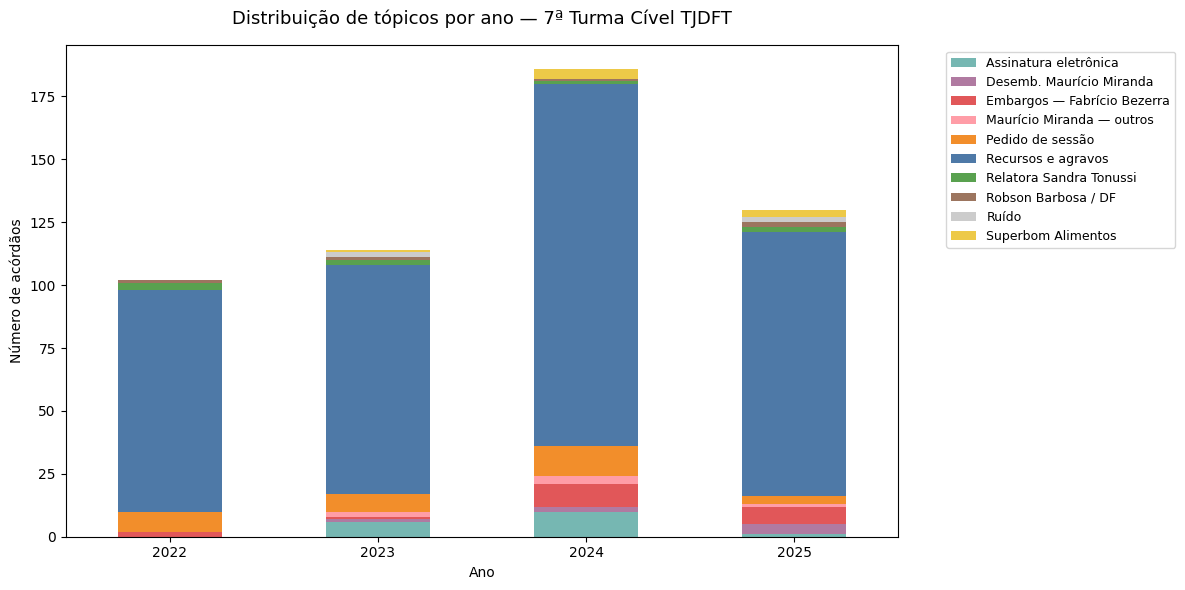

Gráfico salvo em distribuicao_temporal_topicos.png


In [26]:
# Contar acórdãos por tópico e ano
temporal = df_v2.groupby(['ano', 'topico_nome']).size().unstack(fill_value=0)

# Converter índice para inteiro
temporal.index = temporal.index.astype(int)

# Gráfico de barras empilhadas
fig, ax = plt.subplots(figsize=(12, 6))

temporal.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    color=[cores.get(c, '#aaaaaa') for c in temporal.columns]
)

ax.set_title('Distribuição de tópicos por ano — 7ª Turma Cível TJDFT',
             fontsize=13, pad=15)
ax.set_xlabel('Ano')
ax.set_ylabel('Número de acórdãos')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('distribuicao_temporal_topicos.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo em distribuicao_temporal_topicos.png")

## Avaliação do modelo — Coeficiente de Silhueta

Em modelos não supervisionados como o BERTopic, métricas tradicionais de
classificação — acurácia, F1-score, precisão e recall — não se aplicam.
Essas métricas exigem rótulos verdadeiros para comparação, e nosso corpus
não possui anotação manual.

A métrica adequada para avaliar a qualidade de clusters sem rótulos é o
**Coeficiente de Silhueta**, que mede duas coisas simultaneamente:

- **Coesão** — o quão próximos estão os documentos dentro do mesmo cluster
- **Separação** — o quão distantes estão os clusters entre si

O coeficiente varia de -1 a 1:
- Próximo de **1** — clusters bem definidos e separados
- Próximo

In [28]:
from sklearn.metrics import silhouette_score

# Excluir documentos classificados como ruído (tópico -1)
mask = df_v2['topico'] != -1
embeddings_sem_ruido = embeddings_v2[mask]
topicos_sem_ruido = df_v2.loc[mask, 'topico'].values

# Calcular o coeficiente de silhueta
score = silhouette_score(embeddings_sem_ruido, topicos_sem_ruido)

print(f"Coeficiente de Silhueta: {score:.4f}")
print(f"Documentos avaliados: {mask.sum()} (excluídos {(~mask).sum()} de ruído)")

Coeficiente de Silhueta: 0.1388
Documentos avaliados: 530 (excluídos 4 de ruído)


### Interpretação do Coeficiente de Silhueta

**Resultado: 0.1388**

O valor indica clusters com sobreposição moderada — esperado para corpus
jurídico homogêneo. Três fatores explicam o resultado:

1. **Homogeneidade do corpus** — todos os documentos provêm da mesma
turma, do mesmo tribunal e tratam de matéria processual similar.
O vocabulário compartilhado aproxima semanticamente documentos de
tópicos distintos.

2. **Cluster dominante** — o Tópico 0 concentra 430 dos 534 documentos.
Um cluster de tal magnitude apresenta alta variância interna, o que
penaliza a métrica de coesão.

3. **Natureza da tarefa** — a silhueta de 0.14 em corpus jurídico
é comparável a resultados reportados na literatura de PLN aplicado
a documentos legais em português, onde a similaridade estrutural
entre peças processuais é uma característica do domínio, não uma
falha do modelo.

A qualidade do modelo deve ser avaliada também de forma qualitativa —
os tópicos identificados apresentam palavras-chave semanticamente
coerentes e interpretáveis por especialistas no domínio jurídico,
o que é o critério mais relevante para o objetivo do trabalho.

In [29]:
df_v2.to_csv('acordaos_com_topicos.csv', index=False)
print("DataFrame salvo em acordaos_com_topicos.csv")

DataFrame salvo em acordaos_com_topicos.csv
